# INFO6151 - CAPSTONE PROJECT - GROUP #1
## Aleksei Vandyshev, Allyson Fuller, May Kenana
## April 1, 2026

Dataset: Flights (https://www.kaggle.com/datasets/mahoora00135/flights/data)



---
## PURPOSE: Delays and Service Quality of Flights
---
The dataset chosen contains information about flights of airlines in USA. Features include departure and arrival time, delays, flight duration, and distance.

With this dataset, a model will be evaluated and visualizations created to outline the analysis of delays and overall service quality. We can do this by examining delays and arrival time, as well as service quality which can be classified as Good, Fair, and Bad.



### Setup
---

In [60]:
# Import applicable libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

### Importing and defining dataset
---

In [61]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahoora00135/flights")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\allys\.cache\kagglehub\datasets\mahoora00135\flights\versions\1


In [62]:
df = path + "/flights.csv"
df = pd.read_csv(df)

# Check the CSV vs imported data
df.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


#### Define the target:  
1 = delayed arrival (`arr_delay > 15`)

0 = not delayed (`arr_delay <= 15`)

We are performing analysis of delays and overall service quality so we need to define a delayed arrival vs not delayed, and we need to specify service quality. A delayed flight is defined as a flight arriving 15 minutes after it's scheduled arrival time (Anderson & Clinger, 1990).

In [63]:
# The target is delays

# Convert arr_delay
df["arr_delay"] = pd.to_numeric(df["arr_delay"], errors="coerce")

# define is_delayed which is calculated via arr_delay (arrival delay).
df["is_delayed"] = np.where(
    df["arr_delay"].isna(), #Keep NaN
    np.nan,
    (df["arr_delay"] > 15).astype(int) # Delay is considered an arrival over 15 min
)

df["is_delayed"].value_counts(dropna=False)

is_delayed
0.0    249716
1.0     77630
NaN      9430
Name: count, dtype: int64

#### Define service quality:

In [64]:
# Service quality
def service_quality(delay):
    if pd.isna(delay):
        return np.nan
    elif delay <= 0: # Good service, no delay
        return "good"
    elif delay <= 20: # Fair service, 20min delay (5min over defined delay)
        return "fair"
    return "bad" # Over 21min is bad service

df["service_quality"] = df["arr_delay"].apply(service_quality)

df["service_quality"].value_counts(dropna=False)

service_quality
good    194342
bad      66858
fair     66146
NaN       9430
Name: count, dtype: int64

### Exploratory Data Analysis (EDA):  
---

In [65]:
# General information like column names, number of non-null, data-type
print("---INFORMATION---")
df.info()

---INFORMATION---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               336776 non-null  int64  
 1   year             336776 non-null  int64  
 2   month            336776 non-null  int64  
 3   day              336776 non-null  int64  
 4   dep_time         328521 non-null  float64
 5   sched_dep_time   336776 non-null  int64  
 6   dep_delay        328521 non-null  float64
 7   arr_time         328063 non-null  float64
 8   sched_arr_time   336776 non-null  int64  
 9   arr_delay        327346 non-null  float64
 10  carrier          336776 non-null  object 
 11  flight           336776 non-null  int64  
 12  tailnum          334264 non-null  object 
 13  origin           336776 non-null  object 
 14  dest             336776 non-null  object 
 15  air_time         327346 non-null  float64
 16  distance         336

In [66]:
# Null values
print("\n\n---NULL---")
df.isnull().sum()



---NULL---


id                    0
year                  0
month                 0
day                   0
dep_time           8255
sched_dep_time        0
dep_delay          8255
arr_time           8713
sched_arr_time        0
arr_delay          9430
carrier               0
flight                0
tailnum            2512
origin                0
dest                  0
air_time           9430
distance              0
hour                  0
minute                0
time_hour             0
name                  0
is_delayed         9430
service_quality    9430
dtype: int64

#### Balance of our dataset, in terms of target

We can see our dataset is quite unbalanced with total delayed almost three times the amount of total not-delayed

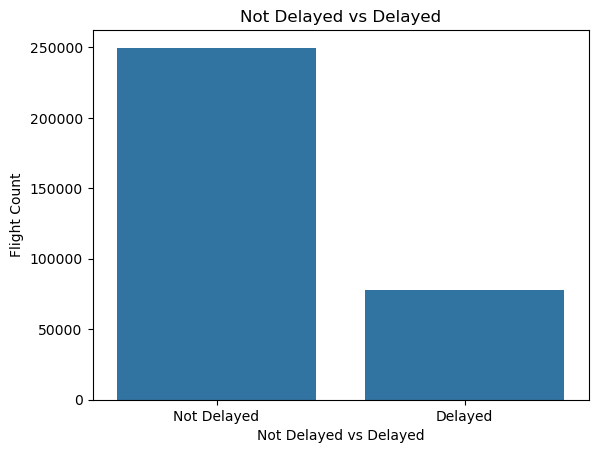

In [67]:
# What is the balance of our dataset, not including NaN values
ax = sns.countplot(x="is_delayed", data=df)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Delayed', 'Delayed'])
plt.xlabel("Not Delayed vs Delayed")
plt.ylabel("Flight Count")
plt.title("Not Delayed vs Delayed")
plt.show()

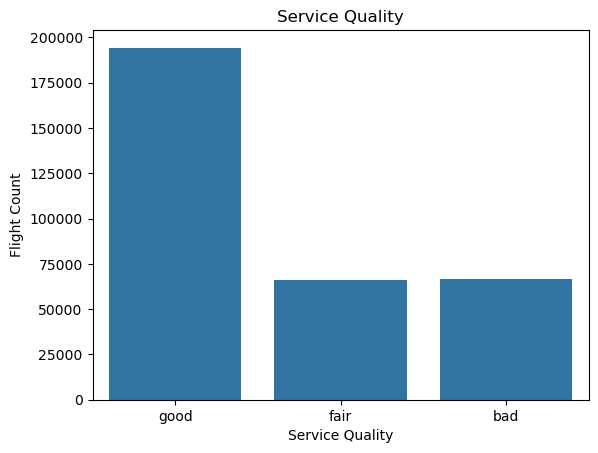

In [68]:
# Comparing service quality, not including NaN values
sns.countplot(x="service_quality", data=df, order=["good","fair","bad"])
plt.xlabel("Service Quality")
plt.ylabel("Flight Count")
plt.title("Service Quality")
plt.show()

#### Arrival delay distribution

Arrival delay is the difference between the actual and scheduled arrival times of the flight, in minutes. A positive value indicates a delayed arrival, while a negative value indicates an early arrival.

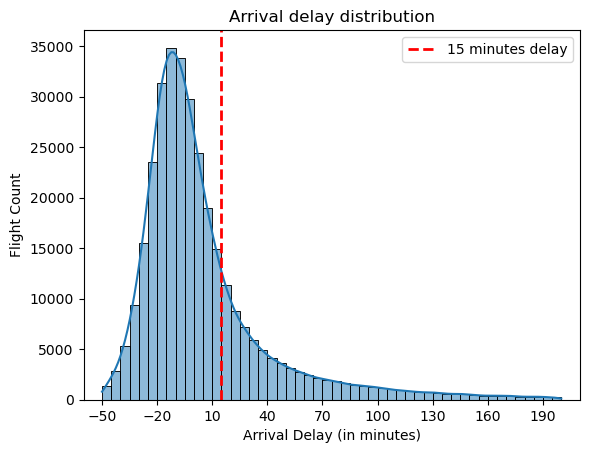

In [69]:
filtered_data = df[df["arr_delay"].between(-50, 200)]

sns.histplot(filtered_data["arr_delay"], bins=50, kde=True)
plt.title("Arrival delay distribution")
plt.xlabel("Arrival Delay (in minutes)")
plt.ylabel("Flight Count")
plt.xlim(-60, 210)

plt.axvline(x=15, color='red', linestyle='--', linewidth=2, label='15 minutes delay')
plt.xticks(np.arange(-50, 211, 30))

plt.legend()
plt.show()

#### Missing Values

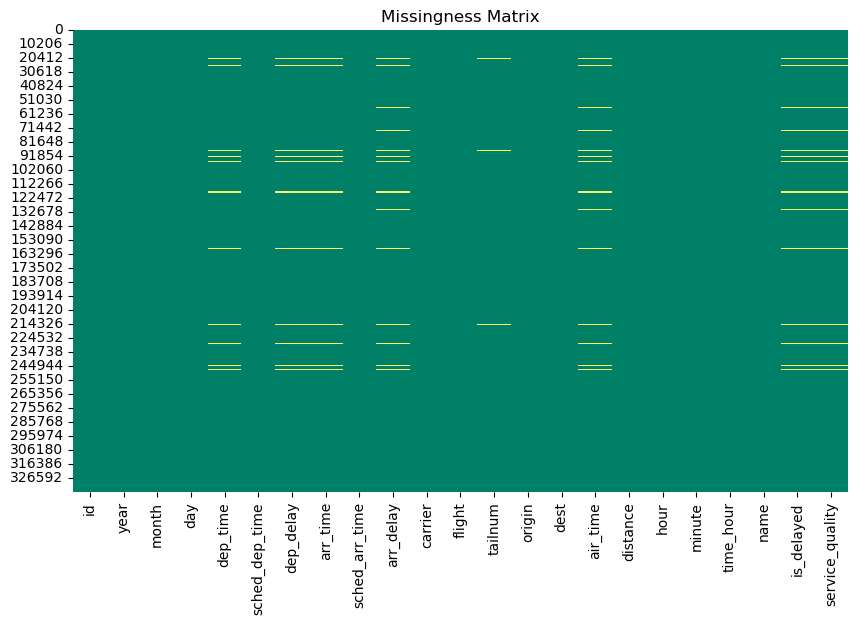

In [70]:
# Create a missingness matrix - what values are missing?
missing_values = df.isnull()

plt.figure(figsize=(10, 6))
sns.heatmap(missing_values, cbar=False, cmap='summer')
plt.title('Missingness Matrix')
plt.show()

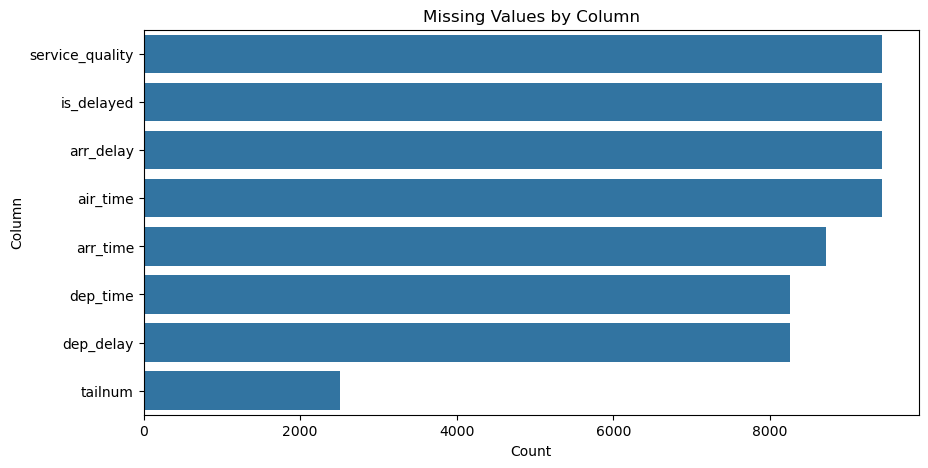

In [71]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.ylabel("Column")
plt.show()

From the missingness matrix we can see a pattern in regards to specific rows. Via the bar graph, we can see missing data primarily in regards to time delays and overall time.

### Data pre-processing
---

#### Feature engineering

In [72]:
# time features
df["dep_hour"] = (df["dep_time"] // 100)
df["dep_minute"] = (df["dep_time"] % 100)

df["sched_dep_hour"] = (df["sched_dep_time"] // 100)
df["sched_arr_hour"] = (df["sched_arr_time"] // 100)

# route
df["route"] = df["origin"] + "_" + df["dest"]

# date
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

#### Imputation

In [73]:
model_df = df.copy()

# Drop all rows where is_delayed is NaN
model_df = model_df.dropna(subset=["is_delayed"])

# drop unnecessary columns
model_df = model_df.drop(columns=["arr_delay", "service_quality", "arr_time", "id", "date"], errors="ignore")

# fill missing numeric values
num_cols = model_df.select_dtypes(include=["int64", "float64"]).columns
model_df[num_cols] = model_df[num_cols].fillna(model_df[num_cols].median())

# fill missing categorical values
cat_cols = model_df.select_dtypes(include=["object"]).columns
model_df[cat_cols] = model_df[cat_cols].fillna("Unknown")

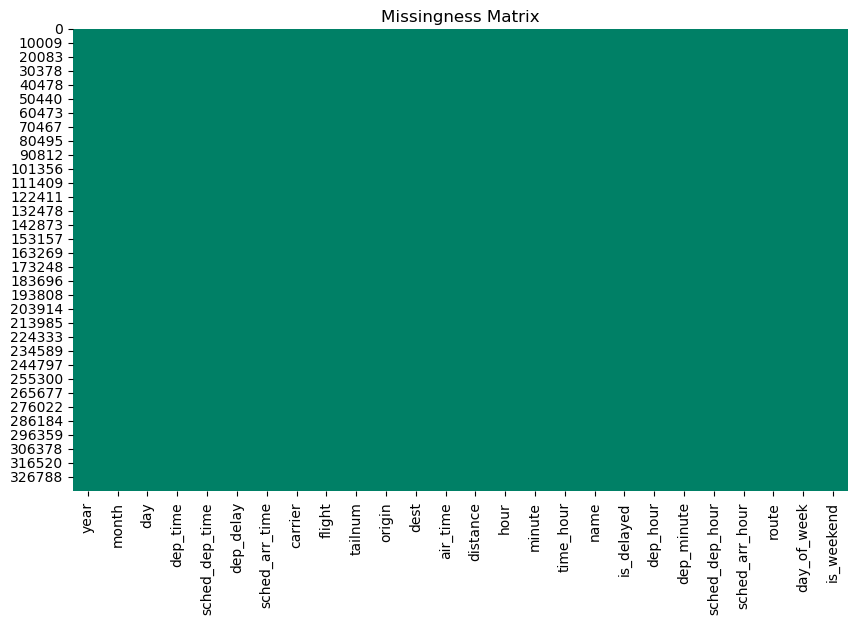

In [74]:
# Missing values sanity check - visually, are there any more NaN values?
missing_values = model_df.isnull()

plt.figure(figsize=(10, 6))
sns.heatmap(missing_values, cbar=False, cmap='summer')
plt.title('Missingness Matrix')
plt.show()

#### Label Encoding

Label encoding was chosen over one-hot encoding because one-hot encoding often adds quite a few more features that dilute feature importance. Objects transformed with label encoding are also less affected by Tree-Based algorithms, with which is what we will be working.

In [77]:
# encode categorical variables
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

In [78]:
# Save new dataframe as a CSV
model_df.to_csv("model_df.csv", index=False)

### Model Evaluation
---

Our primary model chosen was Decision Tree because it works best with a high volume of samples (we have over 300,000), it's easier to interpret, data preparation is minimal, and it is more computationally efficient. We then chose to compare Decision Tree with Random Forest.

#### Split into training and testing

In [79]:
# Train and test

X = model_df.drop(columns=["is_delayed"])
y = model_df["is_delayed"]
print(model_df.columns.tolist())

print(y.value_counts(normalize=True))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay', 'sched_arr_time', 'carrier', 'flight', 'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute', 'time_hour', 'name', 'is_delayed', 'dep_hour', 'dep_minute', 'sched_dep_hour', 'sched_arr_hour', 'route', 'day_of_week', 'is_weekend']
is_delayed
0.0    0.76285
1.0    0.23715
Name: proportion, dtype: float64
X_train shape: (261876, 25)
X_test shape: (65470, 25)


#### Model 1: Decision Tree

Decision tree accuracy: 0.8773178555063388
Decision Tree ROC-AUC: 0.915041820947409
              precision    recall  f1-score   support

         0.0       0.93      0.90      0.92     49944
         1.0       0.72      0.80      0.75     15526

    accuracy                           0.88     65470
   macro avg       0.83      0.85      0.84     65470
weighted avg       0.88      0.88      0.88     65470



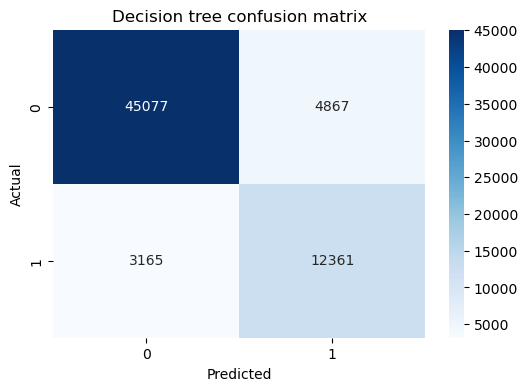

In [80]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print("Decision tree accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt_proba))
print(classification_report(y_test, dt_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Decision tree confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Model 2: Random Forest

Random Forest Accuracy: 0.9084160684282878
Random Forest ROC-AUC: 0.9442622858559979
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     49944
         1.0       0.91      0.68      0.78     15526

    accuracy                           0.91     65470
   macro avg       0.91      0.83      0.86     65470
weighted avg       0.91      0.91      0.90     65470



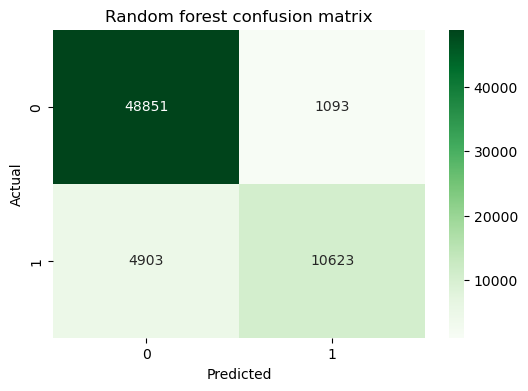

In [81]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Random forest confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Evaluation - Comparing the two Models

ROC Curve

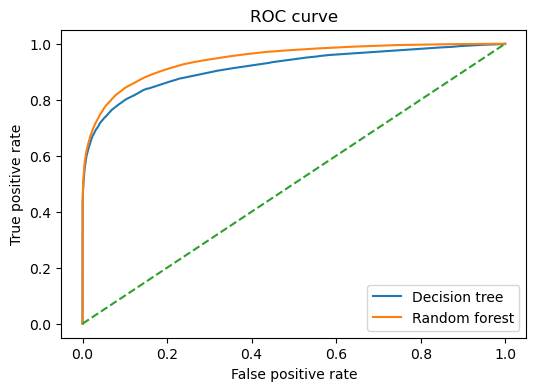

In [82]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label="Decision tree")
plt.plot(rf_fpr, rf_tpr, label="Random forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

Comparing Accuracy and ROC curve of both models

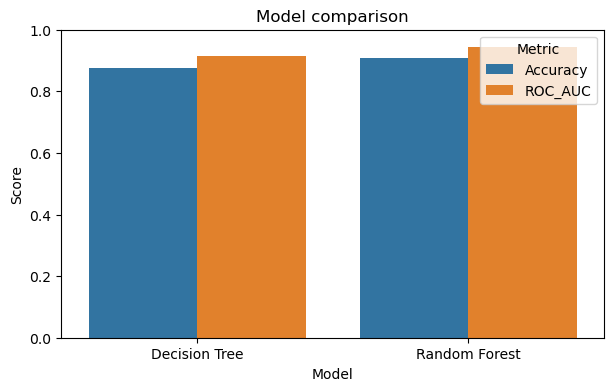

In [83]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, dt_proba),
        roc_auc_score(y_test, rf_proba)
    ]
})

results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(7, 4))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model comparison")
plt.ylim(0, 1)
plt.show()

### Interpretability
---

#### Feature Importance
Feature importance helps us to understand which variables contribute most to the Flight Delay prediction,

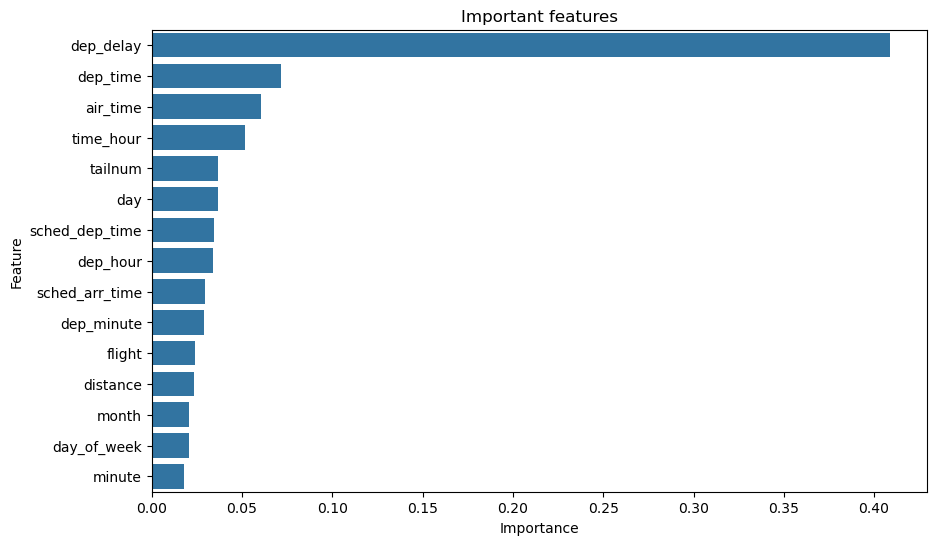

In [84]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Important features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

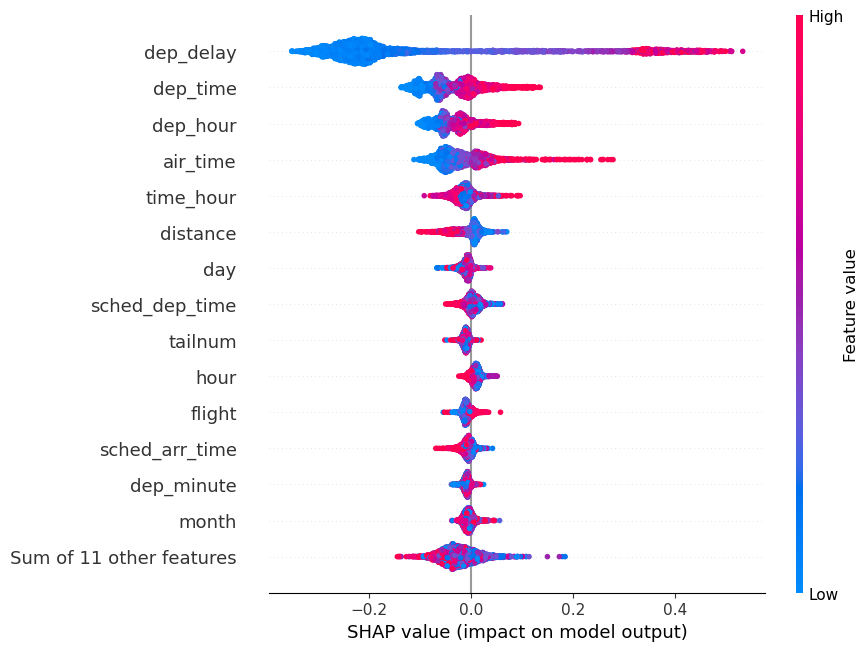

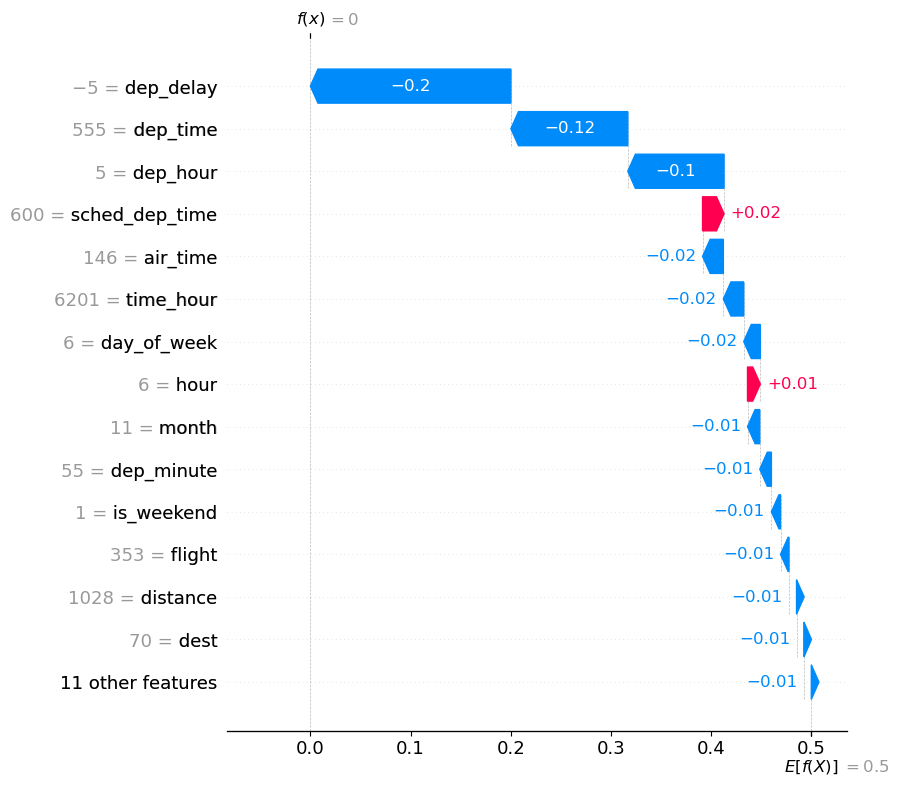

In [ ]:
import shap

X_shap = shap.sample(X_test, min(3367, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent", model_output="raw")

shap_values = explainer(X_shap)
shap.plots.beeswarm(shap_values[..., 1], max_display=15)

local_values = explainer(X_test.iloc[[0]])
shap.plots.waterfall(local_values[0, :, 1], max_display=15)

### Summary
As we can see from the feature importance bar chart, the SHAP value beeswarm chart and the SHAP value waterfall chart, dep_delay AKA departure delay has the most influence on overall flight delay and therefore service quality. With the SHAP values we can see Departure delay, time and hour push the predicition towards a delayed flight, and scheduled departure pushed the prediction towards a flight that is not delayed. 

Below is the code for the interactive dashboard. With the dashboard you can further filter the Overview by Airline, Month, and Route. The dashboard defaults to showing ALL for each category, where you can see the overall arrival delay distribution and service quality mix. We can infer from the arrival delay distribution that most flights are on time or even early, which is mirrored in the service quality mix which outlines most airlines and flight routes are considered "good". We can also see seasonality lending to the data inference via the Monthly delay pattern and Monthly comparison which shows delays occur more often in June, July and December which makes sense because this is when most individuals are on holiday and there is a larger volume of flights. In contrast, September is shown to have flights arrive early! With the Top routes in the current view, we can see which routes have a lower average delay vs route that have a higher average delay, letting us know the flight routes where you may expect more delay. Lastly, we can also compare the airlines, and we can see Frontier Airlines experiences more delays while Alaska and Hawaiian airlines usually arrive early. When you filter this portion by Airline, Month, or Route, you can then home in on a specific metric if you are interested.

Other parts of the interactive dashboard include the Model Performance and Data Explorer. The Data Explorer allows you to view the Filtered flights sample in a tabular form. The Model Performance is a comparison between our two models, Random Forest and Decision Tree. We can see both perform well but overall Random Forest is a bit better, except when it comes to Recall. It is better to predict a flight to be delayed, and it not actually be delayed (under-promise, over-deliver!) which is a False Positive. Therefore we want more False Positives than False Negatives so Recall is more important. In the end we should choose the model with the best Recall which is Decision Tree.



In [ ]:
print(shap_values.values.shape)

(3367, 25, 2)


#### Interactive Dashboard

In [85]:
%pip install dash plotly shap -q

Note: you may need to restart the kernel to use updated packages.


In [86]:
import dash
from dash import Dash, Input, Output, State, dcc, html, dash_table

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

LOGO_BASE64 = "iVBORw0KGgoAAAANSUhEUgAAAFAAAABBCAYAAABGmyOTAAAAAXNSR0IArs4c6QAAAARnQU1BAACxjwv8YQUAAAAJcEhZcwAADsMAAA7DAcdvqGQAABPiSURBVHhe7ZtpfFTV3YCfe+/smck2YVOWEBaRBDCJ/dlWBbvXtdUqVECEor6/irIEtSi2gkLbV+vCZt3qUlu1qC+g1KUJW0ISQDGEJezEJCQBkskkmZnM3Jl773k/3DCSVKAtJOkHno/nrvPM/3/Ouf9zrySEEFzgP0bu3HCBf48LAs+RCwLPkQsCz5ELAs+RHhUoDANd1/hPpwG6oWNoWufmbqVHBRq6TssfXyS8fXvnTWdF/bIS/3PPYYRCnTd1Kz0qULJaiX3+Of4ZM4gcONB582mJHj+Ob8b9xPILkBSl8+ZupUcFAsiJHrTdu2m6dwaRffs6b/4nonV1+Gbch7a5ECkxESSp8y7dSo8LBJA9HvQ9u/HdP5PIwdNHYrS+nsZZs4kVFyG5PZ039wjdJlAYOoZhdGiTAKFpIASSx4O+exe+X84g/DXpHD1+DN+smWhFhcgejxl5ugb/8RB0fug2gZoaZf/zL+Df2zFN5b59EbEYCIHs8WBU7KbpvvuIHNgf3ydaV4/vvpnEijab8pAQkQik9UJyODqcr7uRuquYoMdilN4xjUhDA998/U+4B/QHIHbiBL6HHiL6ySfxyBKBAPKoLNJeegnZ46Hxl/eiFRUiuRNBwtyenY136RIcQ4cRbmwk1hpAkmVTrq4hSTLu9EFIctf2kd0oUGP7vTOpefc9vOOuJnfJM3jSBwEQa/Ljy5vTQaIUakMbMxrFlYDYUorkdLbLbUXOziFt+XLsGRnUF6yn4n+fQm8LI1kUhG6ghcMM+Z+7GH73dKQuHmS6LYVP9lVWj4eW7WVsn5lH8Msqsy01Be/TT2O79jqMQABFCFS3m6q9hwh/9hmKyxWPTCUnF+/zK7BnZFC3bj3lD8wjtHc/0fpjhCurCB04RL8f/oCMiRO6XB7dKxAMLQZIWD0eWr8o4/NZeQSrqwGwer14n/4DjptuIqQbVElWgnYHFocDEKbY7Gy8S5fiSB9MXcEGyuc+TKy5GUtiIpLFggAyZtzDmEULsHbTKN1tAmWrFVvvXuiqCoDlZCTeN5vAl18CYE1NJXHm/fgSU2jRBUp7BBmBIJacHLwrVmAfMsSU98Cv0Jv9KC4XQtPQIhEGT59G1iPzkLtxcn3e+0DN74eIClaL2SAEktWKkpxMqLaWsrwH8RWXYm0fELRggKScbHJfWIHdaqFp5izatmyhyuYiLMkMb27ElTOG1GVmn1dXYKat1tyC4nIiNA09HGbQ9KmMmv8wcvt1tUAA0RoAWTInTLoOsoS1X7/zOvk+7wJbCwpoXfg4MiDZbCAEwtBw3XEnydN/QduxY2yfmYe/eAsWjxskCa2tjZTsbDKsIEpLUJxOVFnmaDDCRdmj6L90KbaMDOry11P+0Dw0f3OnyJtK1vx5yBZTXqikhNZFi0yBFgsYOkYohPPOO0m9//7z2jeed4FGLEbzCy8QWLw4LlFoGsJmJ/GRh0m+5x7ajh/ni5l5+DaXYE1MRACyqjLCULHZrOZwE2hF5H4D7/JluNLTqclfR/mDj6A1N6M4nSAMDE1n8JSJZD78EIrVCkCotBT/zFmImmqw20A3MNrasE+8He/jj2NN9Xa+5XPivAukfbxtfvVVAk8sQhIGkt0OahQBuH/9KCnTp9NWf4wvZuXhK96CxePBIsElIorV0DACQZScHLxLl2IfMoRAxV7Kx09Eb21FcScghMAIBUn56c1kLX0m3pGHSkrxz56JqKtHSkgATcNoC2Of+HO8ixdjcTg73em5oyxYsGBB58ZzRQIc2dmIpCTUwkIkTQO7HXQdtbAQ4fbgGTeWtLFX01Kxh+Chw1jtNtIwkFtbkXNy8C5fjiMjAwDZYsF15CCJe3aTapFJQZAqdNy6hm30KCx9+xEqKcE/axaivh7J5QLDwGgL45g0kbTFi7pEHl0lkLjEyxBJiUQLi5A0zYxEXUMtLMJIcJM49mrSrroS/54KIgcPk6a2YcvJJnX5chyDB8fPpTidOMeNQ62vJ7ajDMliAasVo64Wdft2oppG29NPY9TUmJFn6BhtYZyTJ+F94gkz5buILknhUxFA82uvE3j8cWRhgN2OiKoIJDyPmukcOnacnTNm0jcS5KJly7C3R15ntLY2fPPmEXl3JUqCG0VW8Gs69YbMxYpBkiKbVeq2NpyT7yB10SIUm63zac4rXS6Qdoktr71B6+9+i0WPISkWRNTsEz3zHyHx7nsINzRALIrzoos7H94BLRjEN38+0ZUraXUnUm1xoAqBXYJ0PYonGsY+4ed4Fy5E7oZCQ5el8KmcTGdNkfEXlxJRrMRsdlQD/JtL0N1uUq66CqsnsfOh/4Rss+EaO45Q/THqd+7GYlVwyRIWBLG2MMnX/pg+S5bEpzRdTbc9iWh+P8au3YRlC5WKjcOSlUNON8dlK4HFi2l55ZV/ubInJ7jo89STDLn1pwxu8ZMRizBUj9FfAQ4dIrL9886HdBndIjDa0EDjrFlEVq+mtwz9hIYeUbFFowxSBAmGTsuiRfhfeumsElvy86l6+VUUu50+v/899vG3IYJBJENHsdsw9u/Dd++9hLZt7Xxol9DlKRz1+WjKyyOa/w9ktwdJknCFI9gvvpg0I0ZCWwBhd4BuEC3ajEhIwJGby9c9KwQ3bMA/Zy4H1n5MxGajz1Xfxvmd76DW1hIrL0eyWJDsdkSjj8jmYpTRo7D1N+uOXUWXCoydaKBpzhyi+flfFUuDQZTMTAa8+Dyu4cMJFxaixGIoViuyrhMrKkI4nThycjo8swY3bqQ5by6iqZEWVwJ1xVsxJDkuMVpfj1a2A8naLtHXRKR4c5dL7DKBscZGfHlzia7rKE/OzMK7bCmOSy7BnpmJZrPjLy4lKivEbDaiQtC8YSPSgP4kZGbCycjLy0NuaES4nDRbbGiShK+4BL1douuaa1Dr69B27ECyWpEcX0WiZcxorBd3jcQu6QNjDQ00zp5NLP9T5AQ3gCkvKwvvclMegBoMcWT/IY7Ido4oNo5INg5pcGzQUJTB5lwwtN6UR2MjuJxmcUI3kCwWFIuVg88uYe/S5chOJ2lPPYX9tvHmYrumIblciNpammbcR6i0pMM9ni/OewSqlZU0zJhB9OOPkewOs5DQ1oZlzBi8z6/AMbxdXmsrOx6az7FVa8xokWS0UBB7+iAuW76EtJxsWjZuoHruQzgaTiAnOMEwELpBk2whaghkmxUZaCwuRReCPlddifOaa4jVmU8sQtNAljGOHyeyYRPKpSOwpaf/d5ezghs3Ev7oI2S32ywbGQbCaiNh/G04hg4FIBIIsGPeo5xY/aFZ0pIl9GAIe/ogcpY9S9qY0QQ3rKdx7oMc8rWS6rTTT4ugqSquu+4mNDKTXQsXI9pCyA4nIhZDj0YZOvt+Rs6ZidbWRuCvf4ETjWY5C8ncNyODpMmTzuvbDOdd4NmItLay81ePUv/Bh2bZXZbQQyEcg9PJXvIMaZeNJrBhIy15c9AbGznsTiEkJPpFwwyeOpHU+Y8iKRaq31/F7l8vwIioyA6HKVFVGf7gHEbcP6PzZbuMLukDT4fa0kr5vEep/2AtVrcbFBk9GMKRPojs5c+a8tatozlvDlJDI5LTBQiEEEQlkPsPRFLMJ4yBP7uZzEULkOw2jEjEHDgkidpVHxDxNXW+dJfRbQLVQJDyefM5tuZDLO4EkGW0YMCMvGXPkjZqFMGCAprz5iLFBwwDwxB4ZZ0BQie4eDHNr/4pfs5Bt9zMqMWPIzvspkSLBVlSwOi+pOoWgcGaWrbdfS/Vf37bXLcNBFB9PpwZg8le/gxpY0YTKCjA/8ADSE0+OFnP03W8usYANWKudeg6gScW4X/l5fi5B97yUzIXLYxLNNdAuo9u6QPrNxVRt2oNFrcbSZaRkBAS9L/tFlKzMgnk59M8dy74/WYxVNMwVBXnXXdhzcgguGgRQlXN1zhUFSGBe/6jJN91V/yJpXrVasofeBhXv4u4ctW7OHqldrqLLkL0MIGNm0T1qNGiun9/UTN8uKjJyBDVF10kjj/8sNBjMSGEEP433xRVGUNEzcCB5j7p6aJq0CDR/NprwtD1+Lkq3/mbWP+DG0Sotu6UK3Qt3ZLCp0MA4Q8/QNQe/SrywmHsU6fiXbAgXpJKmjyZxIULEBab+VKRzYYUjRJauRI9GIifL33CeLJ+uxDZ5TrlKl1LjwoEc04rWa2mvEgYx9SppC1c2KGSLLVL9Cx8DGG1mhKtVpBl6NQD9bo8B0dyUoe2rqTHBZrv+ekY4QjOqb8g7ZTI67BbPBIXIqxWiERMgT1Mz9+BrmOEwzin3knqgseQz7CGIQFJkybh+c1vMCwW8w2Iry18dR89LFCgqxEcU6eS+vjC+OL4mZCA5ClT8Dz2GIbVXFvpSbplGnM6DEPQtv0zHJeMwJJ49vWQUzGA0LatOEdc+m8fez7pUYFCnHthRPRwEvdoCp+rPHpYHj0t8L+Fc0nCM6ZwOBzhrbffwefzQXu6aLEYvXv14vbbJ+B2u6muqeG1195gxIgRTBh/a/zYioq9rPlgLd/+1hWMGzcWgBMNJ3jr7b8xKiuL7333OwQDQT5c+xE7d+3CarUyMvNSrhl7NX379mXNmg+pqq5m+i+mkZBgTozfeONNNF3nzimTsbRPdfz+Zl559XUSPYlMmzoZm83GPz4tYOeuXYwf/zMGDhwIwJrVH3K4spLp0+8kKTEJIQR/efMtwqrKz275CR9//Cm19fXxryZiWoxeaWlMm3onNtvpB7czRqBh6OzatYd9+w8SDkeIRFTCkQgR9auRr6iwmLKycjZs3ETN0dp4u8/XRHn5Tt5+eyX79pmfLITDEcrKdlJbWwcI3vnbSj75JJ8+ffpgdzj4+98/oaJiLwCHj1SyY8dOtFM+JqzYu4+Kin0dvjcpKytn65ZtFBYWxa+T4EmguGQLZWXlAAQCQQo3b2br1m3s3lUBQG1dPes3bkLXdWw2K7t27ebAgUPEYhqarqPFNHRNj1/ndPzzjLUTkiSROfJS5ubN6rwJn6+J7du/YOTIkTQ2NrJ16zYG9L8ZAEVRcLkSaGlt5c9vvsX8Rx7C4XBgt9ux2Wzous7Bg4fo1TuNKVMmk5qSzNGjtXi9ZhHAarHE9z2J3W5Hlr8SqsU0Nm8uZvDgdEKhIEVFmxk9ehSjsjIZOHAAFfv28ZOf3MjBQ4fw+5sB2FNRwZVXfov9+/cTDkf45hXfwOl0YhiCzEsvIS9vdvz8/wpnjEAAi8XCsWPHeO+9Vbz//ipWrnyP/e1fEn322ec0t7QwbdoUsrOzKSkuIRgMxo81DJ3c3BxOnDjBX996h4iqYlFkDN1AURSGDhtKTc1RnnzyD7z++psEg0Gc7W9SyYqMqqq8+OLLLF/xAstX/JGGhsZ46gLs2r2Hw0cqufXWm/nRj37IFzvKqak5SmJiIpmZIzlyuJKGhgb2VuwlKSmJzMxMDhw4SFOTnwP7D9K3T2+GDRtKLKZhtVmpqj7KSy/9iZdffpXnn3+R3Xv2xK91Os4qUFEUGht9rN+wgYJ168kvWEdVVTWGYVBSUkpycjKxWIzkpESOn2hg+/ay+LFqNMrYcVdz443Xs2lTEWvXfgSS3D50SkyaeDt33DERq9XKxk2b+O3vnmL16g8AkGUZwzA4WltHTU0NVdU1RKMxJElCbn+EKy4pxWazIksSToedSFuE0i3mGwm5OZehxTSKNpewc/ceRo/K4sYbrsPv91NcUsKBg4cYmXkpbrebWCyGLMuEw2Eqv6yi8ssqDh+ppKW5Nf5bTsdZUzgajTJ8+DDuvmsasiwjhMDtdrNz5y5qjtZiGAbPPP0cAtB1na3bPmPcuKtRFAVhGEjATTdez969+ygpLkFRLCiyuaijxWJcd+2PuOH6a6mpqeHZ55ZTWLSZG66/DmEIHA4HeXNmkZTkQQj43e+fJBaLYbFYqK8/xp49FaiqygsvvgIIJFni8+1fcN11PyYrK5PefXqzbt0G2sJhJk4Yz6UjR+D1evn0kwJC4TYuz82N/041ojJ8+DBmz7rPvHcB8r9QnD2rwJM3nJaW1qG9oGA9LpeTibdPaO+bZLZ9/gVFhZs5fPgwiqKgaRqqqiJJElMmT+IPzzxHVVU1kiwRDodZsmwFkUiEsWNN4aFQiAH9L44fq+sGSUmJ8VFYINB1s2PfuKmQUCjElCmTSElOBqCysor3/28VW0q38P3vf4/MzJGsXvMBQ4cMYejQIdhsNjIzR7JmzVqGDxvK8GHmKiHtfX1dfT1r136ErMjomo7T5eSacWNxnOE1uTOmsCRJJCcn40pI6DDy1Rw9Sk3tUa666iquvPLbXH55Ljk52dx043Wk9fJSVrYTSZHwpnmx2+wAXHRxPyZOnGCOuDYbdpuNK674BoZhsPLd9/nr2+/Qr19ffj5hPJIs4XK5SElJigsDSPQkkpqaSmNjIwcOHiQ3N4fvf++75ObmkJubw/XX/5ghQzIo37UbwzDIzh6Dx+1mzJhRJLgTABgzZgwej5vRo7Nwe8xFf0mSSE1LRVVV1q3fQH7+Oj75Rz7FxaVEz/KsfcZ5oGEY+P1+FMVC8ik1tnA4THNLC6kpKdjtpqCTNPp8SEgkJLhoaW0lKTGxwz/o8zVhs1nxeMwvidraQvh8fgxh0DutF06XOYi0NLcQ1WJ4U1PjfV5Tkx8kSHC5aG5uwe12x6PzJC2traiqSq+0NAzD4PjxE+1RbArUNI0TJxo6tBmGQXNzszllkiQQZrRbFIWUlJT49b+OMwq8wNk5vdoL/EtcEHiOXBB4jlwQeI5cEHiO/D8wfQeNmSHgvAAAAABJRU5ErkJggg=="

##### Dashboard style

In [87]:
COLORS = {
    "primary": "#AE1F36",
    "primary_dark": "#7E1527",
    "secondary": "#1F1F1F",
    "accent": "#D9DDE3",
    "paper": "#F7F8FA",
    "card": "#FFFFFF",
    "muted": "#6B7280",
    "success": "#16803C",
    "grid": "rgba(31,31,31,0.08)",
    "shadow": "rgba(31,31,31,0.08)",
    "shadow_strong": "rgba(31,31,31,0.18)",
    "info_bg": "#F5F7FA",
    "info_border": "#E5E7EB",
}

LOGO_SRC = f"data:image/png;base64,{LOGO_BASE64}"
CHART_SEQUENCE = [COLORS["primary"], COLORS["secondary"], "#9CA3AF", "#D9DDE3"]

PAGE_STYLE = {
    "backgroundColor": COLORS["paper"],
    "minHeight": "100vh",
    "padding": "clamp(12px, 2vw, 24px)",
    "fontFamily": "Arial, sans-serif",
    "maxWidth": "1600px",
    "margin": "0 auto",
    "boxSizing": "border-box",
    "width": "100%",
}

HERO_STYLE = {
    "background": f"linear-gradient(135deg, {COLORS['primary']} 0%, {COLORS['primary_dark']} 100%)",
    "borderRadius": "24px",
    "padding": "14px 18px",
    "color": "white",
    "boxShadow": f"0 12px 28px {COLORS['shadow_strong']}",
    "marginBottom": "18px",
}

HERO_INNER_STYLE = {
    "display": "grid",
    "gridTemplateColumns": "140px 1fr",
    "gap": "18px",
    "alignItems": "center",
}

LOGO_CARD_STYLE = {
    "borderRadius": "18px",
    "padding": "10px",
    "display": "flex",
    "alignItems": "center",
    "justifyContent": "center",
    "minHeight": "84px",
    "width": "100%",
    "boxShadow": "0 8px 18px rgba(0,0,0,0.10)",
    "boxSizing": "border-box",
}

LOGO_STYLE = {
    "width": "100%",
    "maxWidth": "80px",
    "height": "auto",
    "display": "block",
    "objectFit": "contain",
}

EYEBROW_STYLE = {
    "fontSize": "0.78rem",
    "opacity": 0.95,
    "letterSpacing": "0.04em",
    "textTransform": "uppercase",
    "marginBottom": "4px",
}

HERO_TITLE_STYLE = {
    "margin": "2px 0 4px 0",
    "fontSize": "clamp(1.35rem, 2.4vw, 2rem)",
    "fontWeight": 800,
    "lineHeight": 1.05,
}

HERO_TEXT_STYLE = {
    "fontSize": "0.92rem",
    "maxWidth": "820px",
    "lineHeight": 1.35,
    "margin": 0,
}

PANEL_STYLE = {
    "background": COLORS["card"],
    "padding": "clamp(14px, 2vw, 18px)",
    "borderRadius": "18px",
    "boxShadow": f"0 8px 22px {COLORS['shadow']}",
    "width": "100%",
    "boxSizing": "border-box",
    "overflow": "hidden",
}

CARD_STYLE = {
    "background": COLORS["card"],
    "borderRadius": "18px",
    "padding": "18px 20px",
    "boxShadow": f"0 8px 22px {COLORS['shadow']}",
    "borderTop": f"4px solid {COLORS['primary']}",
    "width": "100%",
    "boxSizing": "border-box",
    "minWidth": 0,
}

FILTER_PANEL_STYLE = {**PANEL_STYLE, "marginBottom": "18px"}
FILTER_HEADER_ROW_STYLE = {
    "display": "flex",
    "justifyContent": "space-between",
    "alignItems": "flex-start",
    "gap": "16px",
    "flexWrap": "wrap",
    "marginBottom": "14px",
}
FILTER_GRID_STYLE = {
    "display": "grid",
    "gridTemplateColumns": "repeat(auto-fit, minmax(250px, 1fr))",
    "gap": "16px",
    "alignItems": "start",
}
FILTER_CONTROL_STYLE = {
    "background": COLORS["info_bg"],
    "border": f"1px solid {COLORS['info_border']}",
    "borderRadius": "14px",
    "padding": "14px",
}

INFO_BANNER_STYLE = {
    "background": COLORS["info_bg"],
    "border": f"1px solid {COLORS['info_border']}",
    "borderRadius": "14px",
    "padding": "12px 14px",
    "marginBottom": "14px",
    "color": COLORS["secondary"],
    "lineHeight": 1.5,
}

SECTION_BLOCK_STYLE = {"display": "grid", "gap": "16px", "paddingTop": "18px"}
KPI_GRID_STYLE = {
    "display": "grid",
    "gridTemplateColumns": "repeat(auto-fit, minmax(220px, 1fr))",
    "gap": "16px",
    "marginBottom": "18px",
    "alignItems": "stretch",
}
TWO_COL_GRID_STYLE = {
    "display": "grid",
    "gridTemplateColumns": "repeat(auto-fit, minmax(320px, 1fr))",
    "gap": "18px",
    "alignItems": "stretch",
}

TITLE_SM = {"fontSize": "0.9rem", "color": COLORS["muted"], "marginBottom": "4px", "lineHeight": 1.3}
VALUE_LG = {"fontSize": "clamp(1.4rem, 3vw, 1.9rem)", "fontWeight": 700, "color": COLORS["secondary"], "lineHeight": 1.15}
SUBTEXT_SM = {"fontSize": "0.8rem", "color": COLORS["muted"]}
SECTION_TITLE_STYLE = {"marginTop": 0, "marginBottom": "6px", "color": COLORS["secondary"]}
SECTION_TEXT_STYLE = {"margin": 0, "lineHeight": 1.6, "color": COLORS["muted"]}
LABEL_STYLE = {"fontWeight": 600, "color": COLORS["secondary"], "display": "block", "marginBottom": "6px"}

DATA_TABLE_STYLE = {
    "style_table": {"overflowX": "auto", "width": "100%", "minWidth": "100%"},
    "fill_width": True,
    "style_header": {
        "backgroundColor": COLORS["secondary"],
        "color": "white",
        "fontWeight": "bold",
        "border": "none",
    },
    "style_cell": {
        "padding": "10px",
        "fontFamily": "Arial, sans-serif",
        "textAlign": "center",
        "border": "1px solid #EEF1F4",
        "minWidth": "110px",
        "width": "110px",
        "maxWidth": "220px",
    },
}

DATA_EXPLORER_TABLE_STYLE = {
    "style_table": {"overflowX": "auto", "width": "100%", "minWidth": "100%", "maxHeight": "70vh"},
    "fill_width": True,
    "style_header": {
        "backgroundColor": COLORS["secondary"],
        "color": "white",
        "fontWeight": "bold",
        "border": "none",
        "position": "sticky",
        "top": 0,
        "zIndex": 1,
    },
    "style_cell": {
        "padding": "10px",
        "fontFamily": "Arial, sans-serif",
        "textAlign": "left",
        "maxWidth": "160px",
        "whiteSpace": "normal",
        "border": "1px solid #EEF1F4",
        "minWidth": "110px",
        "width": "110px",
    },
}

TAB_COLORS = {"border": COLORS["accent"], "primary": COLORS["primary"], "background": COLORS["card"]}

def apply_theme(fig, title, height=420, show_legend=True):
    fig.update_layout(
        title=dict(text=title, x=0.02, xanchor="left"),
        template="plotly_white",
        height=height,
        autosize=True,
        paper_bgcolor=COLORS["card"],
        plot_bgcolor=COLORS["card"],
        font=dict(color=COLORS["secondary"]),
        title_font=dict(size=18, color=COLORS["secondary"]),
        margin=dict(l=24, r=18, t=68, b=72 if show_legend else 28),
        legend=dict(orientation="h",  yanchor="top", y=-0.18,  xanchor="center", x=0.5,  title=None,),
        colorway=CHART_SEQUENCE,
        showlegend=show_legend,
    )
    fig.update_xaxes(showgrid=False, automargin=True)
    fig.update_yaxes(gridcolor=COLORS["grid"], automargin=True)
    return fig

def responsive_graph(graph_id, min_height="380px"):
    return html.Div(
        style={"width": "100%", "height": min_height, "minHeight": min_height},
        children=[
            dcc.Graph(id=graph_id, config={"displayModeBar": False, "responsive": True}, style={"width": "100%", "height": min_height, "minHeight": min_height, "display": "block"}, )
        ],
    )

def static_graph(figure, min_height="420px"):
    return html.Div(style={"width": "100%", "height": min_height, "minHeight": min_height}, children=[
            dcc.Graph( figure=figure, config={"displayModeBar": False, "responsive": True},  style={"width": "100%", "height": min_height, "minHeight": min_height, "display": "block"}, )
        ],
    )

def metric_card(title, value, subtitle=None):
    return html.Div(
        [html.Div(title, style=TITLE_SM), html.Div(value, style=VALUE_LG), html.Div(subtitle or "", style=SUBTEXT_SM)],
        style=CARD_STYLE,
    )

def empty_figure(title, message):
    fig = go.Figure()
    fig.add_annotation(text=message, x=0.5, y=0.5,  xref="paper", yref="paper", showarrow=False, font=dict(size=16, color=COLORS["muted"]),  )
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)
    return apply_theme(fig, title, height=420, show_legend=False)

##### Dashboard preprocessing

In [88]:
import shap

dashboard_df = df.copy()

TEXT_COLUMNS = ["carrier", "origin", "dest"]
NUMERIC_COLUMNS = ["month", "day", "air_time", "dep_delay", "arr_delay"]

DISPLAY_COLUMNS = [
    "airline_name", "origin", "dest", "route", "month_name", "day",
    "dep_delay", "arr_delay", "air_time", "service_quality", "is_delayed",
]
DISPLAY_NAME_MAP = {
    "airline_name": "Airline",
    "origin": "Origin",
    "dest": "Destination",
    "route": "Route",
    "month_name": "Month",
    "day": "Day",
    "dep_delay": "Departure delay",
    "arr_delay": "Arrival delay",
    "air_time": "Air time",
    "service_quality": "Service quality",
    "is_delayed": "Delayed",
}
SERVICE_COLOR_MAP = {
    "good": COLORS["success"],
    "fair": COLORS["accent"],
    "bad": COLORS["primary"],
}

for col in TEXT_COLUMNS:
    if col not in dashboard_df.columns:
        dashboard_df[col] = pd.NA
    dashboard_df[col] = (
        dashboard_df[col]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "Unknown": pd.NA})
    )

for col in NUMERIC_COLUMNS:
    if col not in dashboard_df.columns:
        dashboard_df[col] = np.nan
    dashboard_df[col] = pd.to_numeric(dashboard_df[col], errors="coerce")

if "is_delayed" not in dashboard_df.columns:
    dashboard_df["is_delayed"] = (dashboard_df["arr_delay"] > 15).astype(int)
else:
    dashboard_df["is_delayed"] = (
        pd.to_numeric(dashboard_df["is_delayed"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

def service_quality(delay):
    if pd.isna(delay):
        return pd.NA
    if delay <= 0:
        return "good"
    if delay <= 20:
        return "fair"
    return "bad"

if "service_quality" not in dashboard_df.columns:
    dashboard_df["service_quality"] = dashboard_df["arr_delay"].apply(service_quality)
else:
    dashboard_df["service_quality"] = (
        dashboard_df["service_quality"]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "Unknown": pd.NA})
    )

month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
month_order = [month_map[i] for i in sorted(month_map)]

dashboard_df["month_name"] = dashboard_df["month"].map(month_map)
dashboard_df["month_name"] = pd.Categorical(
    dashboard_df["month_name"],
    categories=month_order,
    ordered=True,
)

if "name" in dashboard_df.columns:
    dashboard_df["airline_name"] = (
        dashboard_df["name"]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "Unknown": pd.NA})
    )
else:
    dashboard_df["airline_name"] = (
        dashboard_df["carrier"]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "Unknown": pd.NA})
    )

dashboard_df["airline_name"] = dashboard_df["airline_name"].fillna(
    dashboard_df["carrier"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "Unknown": pd.NA})
)

dashboard_df["route"] = np.where(
    dashboard_df["origin"].notna() & dashboard_df["dest"].notna(),
    dashboard_df["origin"].astype(str) + " → " + dashboard_df["dest"].astype(str),
    pd.NA,
)

airline_options = [{"label": airline, "value": airline}
    for airline in sorted(dashboard_df["airline_name"].dropna().unique())
]
month_options = [{"label": month_map[int(month)], "value": int(month)}
    for month in sorted(dashboard_df["month"].dropna().astype(int).unique())
    if int(month) in month_map
]
route_counts_all = (
    dashboard_df["route"].dropna().astype(str).value_counts().sort_values(ascending=False).head(100)
)
route_options = [{"label": f"{route} ({count:,})", "value": route}
    for route, count in route_counts_all.items()
]

##### Preprocessing module assets

In [89]:
preprocess_cards = [
    metric_card("Original rows", f"{len(df):,}", "raw dataset"),
    metric_card("Rows used for model", f"{len(model_df):,}", "after target cleanup"),
    metric_card("Model features", f"{X.shape[1]:,}", "used in training"),
    metric_card("Dropped columns", "5", "arr_delay, service_quality, arr_time, id, date"),
]

missing_before = df.isna().sum().sort_values(ascending=False)
missing_after = model_df.isna().sum().sort_values(ascending=False)

top_missing_cols = (
    missing_before[missing_before > 0]
    .head(10)
    .index
    .tolist()
)
if not top_missing_cols:
    top_missing_cols = missing_before.head(10).index.tolist()

missing_compare_df = pd.DataFrame({
    "Feature": top_missing_cols,
    "Before preprocessing": [missing_before.get(col, 0) for col in top_missing_cols],
    "After preprocessing": [missing_after.get(col, 0) for col in top_missing_cols],
}).melt(id_vars="Feature", var_name="Stage", value_name="Missing values")

preprocessing_missing_fig = px.bar(
    missing_compare_df,
    x="Feature",
    y="Missing values",
    color="Stage",
    barmode="group",
)
preprocessing_missing_fig = apply_theme(preprocessing_missing_fig, "Missing values before vs after preprocessing")

balance_before = df["is_delayed"].dropna().value_counts().sort_index()
balance_after = model_df["is_delayed"].dropna().value_counts().sort_index()

balance_df = pd.DataFrame({
    "Class": ["On time / low delay", "Delayed > 15 min"],
    "Before preprocessing": [balance_before.get(0, 0), balance_before.get(1, 0)],
    "After preprocessing": [balance_after.get(0, 0), balance_after.get(1, 0)],
}).melt(id_vars="Class", var_name="Stage", value_name="Count")

preprocessing_balance_fig = px.bar(
    balance_df,
    x="Class",
    y="Count",
    color="Stage",
    barmode="group",
)
preprocessing_balance_fig = apply_theme(preprocessing_balance_fig, "Target balance before vs after preprocessing")

dtype_summary_df = pd.DataFrame({
    "Dataset": ["Raw df", "Raw df", "Model df", "Model df"],
    "Type": ["Numeric", "Categorical", "Numeric", "Categorical"],
    "Count": [
        int(df.select_dtypes(include=["number"]).shape[1]),
        int(df.select_dtypes(exclude=["number"]).shape[1]),
        int(model_df.select_dtypes(include=["number"]).shape[1]),
        int(model_df.select_dtypes(exclude=["number"]).shape[1]),
    ],
})

preprocessing_structure_fig = px.bar(
    dtype_summary_df,
    x="Dataset",
    y="Count",
    color="Type",
    barmode="group",
)
preprocessing_structure_fig = apply_theme(preprocessing_structure_fig, "Feature types before and after preprocessing")


##### Model evaluation assets

In [90]:
model_metrics_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, dt_pred), accuracy_score(y_test, rf_pred)],
    "Precision": [precision_score(y_test, dt_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, dt_pred), recall_score(y_test, rf_pred)],
    "F1-score": [f1_score(y_test, dt_pred), f1_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, dt_proba), roc_auc_score(y_test, rf_proba)],
}).round(3)

model_metrics_long_df = model_metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
model_comparison_fig = px.bar(
    model_metrics_long_df,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    text="Score",
)
model_comparison_fig.update_traces(texttemplate="%{text:.3f}", textposition="outside", cliponaxis=False)
model_comparison_fig.update_yaxes(range=[0, 1.05])
model_comparison_fig = apply_theme(model_comparison_fig, "Model metrics comparison")

model_metrics_table = dash_table.DataTable(
    data=model_metrics_df.to_dict("records"),
    columns=[{"name": col, "id": col} for col in model_metrics_df.columns],
    **DATA_TABLE_STYLE,
)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

roc_fig = go.Figure()
roc_fig.add_trace(go.Scatter(x=dt_fpr, y=dt_tpr, mode="lines", name="Decision Tree"))
roc_fig.add_trace(go.Scatter(x=rf_fpr, y=rf_tpr, mode="lines", name="Random Forest"))
roc_fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode="lines", name="Baseline", line=dict(dash="dash", color="#9CA3AF")))
roc_fig.update_xaxes(title_text="False positive rate")
roc_fig.update_yaxes(title_text="True positive rate")
roc_fig = apply_theme(roc_fig, "")

def build_confusion_figure(cm, title):
    fig = go.Figure(
        data=go.Heatmap(z=cm, x=["Predicted (not delayed)", "Predicted (delayed arrival)"], y=["Actual (not delayed)", "Actual (delayed arrival)"], colorscale=[[0, "#F2F4F7"], [1, COLORS["primary"]]], showscale=False,)
    )
    threshold = cm.max() / 2 if cm.max() else 0
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            fig.add_annotation(
                x=c, y=r, text=str(cm[r, c]), showarrow=False,
                font=dict(color="white" if cm[r, c] > threshold else COLORS["secondary"], size=16),
            )
    return apply_theme(fig, title, show_legend=False)

dt_confusion_fig = build_confusion_figure(confusion_matrix(y_test, dt_pred),"")
rf_confusion_fig = build_confusion_figure(confusion_matrix(y_test, rf_pred),"")


##### Interpretability assets

In [91]:
dt_importance = pd.DataFrame({"feature": X.columns, "importance": dt.feature_importances_, "Model": "Decision Tree"})
rf_importance = pd.DataFrame({"feature": X.columns, "importance": rf.feature_importances_, "Model": "Random Forest"})
combined_importance = pd.concat([dt_importance, rf_importance], ignore_index=True)

top_features_union = (combined_importance.groupby("feature")["importance"].max().sort_values(ascending=False).head(12).index)

importance_compare_df = combined_importance[combined_importance["feature"].isin(top_features_union)]

importance_compare_fig = px.bar(importance_compare_df.sort_values("importance"), x="importance",  y="feature", color="Model", barmode="group", orientation="h",)
importance_compare_fig = apply_theme(importance_compare_fig, "Feature importance comparison")

SHAP_SAMPLE_SIZE = min(200, len(X_test))
X_shap_dash = shap.sample(X_test, SHAP_SAMPLE_SIZE, random_state=42)
explainer_dash = shap.TreeExplainer(rf)
shap_values_dash = explainer_dash(X_shap_dash)

if shap_values_dash.values.ndim == 3:
    shap_matrix = shap_values_dash.values[:, :, 1]
    shap_base = shap_values_dash.base_values[:, 1]
else:
    shap_matrix = shap_values_dash.values
    shap_base = shap_values_dash.base_values

global_shap_df = (
    pd.DataFrame({
        "feature": X_shap_dash.columns,
        "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

shap_global_fig = px.bar(
    global_shap_df.sort_values("mean_abs_shap"),
    x="mean_abs_shap",
    y="feature",
    orientation="h",
    color_discrete_sequence=[COLORS["primary"]],
    labels={"mean_abs_shap": "Mean |SHAP|", "feature": "Feature"},
)
shap_global_fig = apply_theme(shap_global_fig, "SHAP global importance (Random Forest)", show_legend=False)

local_idx = 0
local_contrib_df = (
    pd.DataFrame({
        "feature": X_shap_dash.columns,
        "shap_value": shap_matrix[local_idx],
        "feature_value": X_shap_dash.iloc[local_idx].values,
    })
    .assign(direction=lambda d: np.where(d["shap_value"] >= 0, "Increase", "Decrease"))
    .sort_values("shap_value", key=np.abs, ascending=False)
    .head(12)
)

shap_local_fig = px.bar(local_contrib_df.sort_values("shap_value"),  x="shap_value", y="feature", orientation="h", color="direction", hover_data={"feature_value": True, "shap_value": ':.4f'},
    color_discrete_map={"Increase": COLORS["primary"], "Decrease": COLORS["secondary"]}, labels={"shap_value": "SHAP contribution", "feature": "Feature"},
)
shap_local_fig = apply_theme(shap_local_fig, "Local SHAP explanation (first sampled row)")

interpretability_note = html.Div(
    style=INFO_BANNER_STYLE,
    children=[
        html.Strong("Interpretability note: "),
        html.Span(
            f"SHAP is calculated on a representative sample of {SHAP_SAMPLE_SIZE} rows "
            "from X_test for speed. The local explanation uses the first sampled observation."
        ),
    ],
)

##### Dashboard layout

In [92]:
app = Dash(__name__, meta_tags=[{"name": "viewport", "content": "width=device-width, initial-scale=1"}])
app.title = "INFO-6151. Flight delay dashboard"

app.layout = html.Div(style=PAGE_STYLE, children=[
    html.Div(style=HERO_STYLE, children=[
        html.Div(style=HERO_INNER_STYLE, children=[
            html.Div(style=LOGO_CARD_STYLE, children=[html.Img(src=LOGO_SRC, alt="Fanshawe logo", style=LOGO_STYLE)]),
            html.Div(
                [
                    html.Div("INFO-6151 Capstone", style=EYEBROW_STYLE),
                    html.H1("Flight delay dashboard", style=HERO_TITLE_STYLE),
                    html.Div("Delays and service quality of flights", style=HERO_TEXT_STYLE,
                             ),
                             ]
                        ),
                    ],
                )
            ],
        ),
        html.Div(style=FILTER_PANEL_STYLE, children=[
                html.Div(style=FILTER_HEADER_ROW_STYLE, children=[
                        html.Div(
                            [
                                html.H3("Interactive filters", style=SECTION_TITLE_STYLE),
                                html.P("Use airline, month, and route filters to update the tabs.", style=SECTION_TEXT_STYLE,),
                            ]
                        )
                    ],
                ),
                html.Div(style=FILTER_GRID_STYLE, children=[
                        html.Div(style=FILTER_CONTROL_STYLE, children=[
                                html.Label("Airline", style=LABEL_STYLE),
                                dcc.Dropdown(id="airline-dropdown", options=airline_options, value=[], multi=True, placeholder="All airlines"),
                            ],
                        ),
                        html.Div(style=FILTER_CONTROL_STYLE, children=[
                                html.Label("Month", style=LABEL_STYLE),
                                dcc.Dropdown(id="month-dropdown", options=month_options, value=[], multi=True, placeholder="All months"),
                            ],
                        ),
                        html.Div(style=FILTER_CONTROL_STYLE, children=[
                                html.Label("Route", style=LABEL_STYLE),
                                dcc.Dropdown(id="route-dropdown", options=route_options, value=[], multi=True, placeholder="All routes"),
                            ],
                        ),
                    ],
                ),
            ],
        ),
        html.Div(id="kpi-row", style=KPI_GRID_STYLE),
        dcc.Tabs(id="main-tabs", value="data-overview", colors=TAB_COLORS, children=[
                dcc.Tab(label="Data Overview", value="data-overview", children=[
                        html.Div(style=SECTION_BLOCK_STYLE, children=[
                                html.Div(style=INFO_BANNER_STYLE, children=[
                                    html.Strong("Purpose: "),
                                    html.Span("Interactive EDA over the original flight data, filtered by airline, month and route."),
                                ]),
                                html.Div(style=TWO_COL_GRID_STYLE, children=[responsive_graph("delay-hist"), responsive_graph("service-donut")]),
                                html.Div(style=TWO_COL_GRID_STYLE, children=[responsive_graph("monthly-trend"), responsive_graph("top-routes")]),
                                html.Div(style=TWO_COL_GRID_STYLE, children=[responsive_graph("month-compare"), responsive_graph("airline-compare")]),
                            ],
                        )
                    ],
                ),
                dcc.Tab(label="Preprocessing", value="preprocessing", children=[
                        html.Div(style=SECTION_BLOCK_STYLE, children=[
                                html.Div(style=INFO_BANNER_STYLE, children=[
                                    html.Strong("Purpose: "),
                                    html.Span("Show what changed between the raw dataset and the modeling dataset after feature engineering, dropping leakage, and cleaning."),
                                ]),
                                html.Div(style=KPI_GRID_STYLE, children=preprocess_cards),
                                html.Div(style=TWO_COL_GRID_STYLE, children=[static_graph(preprocessing_missing_fig, "420px"), static_graph(preprocessing_balance_fig, "420px"),]),
                                html.Div(style=PANEL_STYLE, children=[
                                    html.H3("Dataset structure", style=SECTION_TITLE_STYLE),
                                    static_graph(preprocessing_structure_fig, "420px"),
                                ]),
                            ],
                        )
                    ],
                ),
                dcc.Tab(label="Model Evaluation", value="model-evaluation", children=[
                        html.Div(style=SECTION_BLOCK_STYLE, children=[
                                html.Div(style=INFO_BANNER_STYLE, children=[
                                    html.Strong("Purpose: "),
                                    html.Span("Compare the trained Decision Tree and Random Forest models using classification metrics, ROC curves, and confusion matrices."),
                                ]),
                                html.Div(style=TWO_COL_GRID_STYLE, children=[
                                    html.Div(style=PANEL_STYLE, children=[
                                        html.H3("Metrics comparison", style=SECTION_TITLE_STYLE),
                                        static_graph(model_comparison_fig, "420px"),
                                    ]),
                                    html.Div(style=PANEL_STYLE, children=[
                                        html.H3("Metrics table", style=SECTION_TITLE_STYLE),
                                        model_metrics_table,
                                    ]),
                                ]),
                                html.Div(style=TWO_COL_GRID_STYLE, children=[
                                    html.Div(style=PANEL_STYLE, children=[
                                        html.H3("Decision Tree confusion", style=SECTION_TITLE_STYLE),
                                        static_graph(dt_confusion_fig, "420px"),
                                    ]),
                                    html.Div(style=PANEL_STYLE, children=[
                                        html.H3("Random Forest confusion", style=SECTION_TITLE_STYLE),
                                        static_graph(rf_confusion_fig, "420px"),
                                    ]),
                                ]),
                                html.Div(style=PANEL_STYLE, children=[
                                    html.H3("ROC curves", style=SECTION_TITLE_STYLE),
                                    static_graph(roc_fig, "420px"),
                                ]),
                            ],
                        )
                    ],
                ),
                dcc.Tab(label="Interpretability", value="interpretability", children=[
                        html.Div(style=SECTION_BLOCK_STYLE, children=[
                                interpretability_note,
                                html.Div(style=TWO_COL_GRID_STYLE, children=[
                                    html.Div(style=PANEL_STYLE, children=[
                                        html.H3("Feature importance comparison", style=SECTION_TITLE_STYLE),
                                        static_graph(importance_compare_fig, "420px"),
                                    ]),
                                    html.Div(style=PANEL_STYLE, children=[
                                        html.H3("Global SHAP importance", style=SECTION_TITLE_STYLE),
                                        static_graph(shap_global_fig, "420px"),
                                    ]),
                                ]),
                                html.Div(style=PANEL_STYLE, children=[
                                    html.H3("Local SHAP explanation", style=SECTION_TITLE_STYLE),
                                    static_graph(shap_local_fig, "460px"),
                                ]),
                            ],
                        )
                    ],
                ),
                dcc.Tab(label="Data Explorer", value="data-explorer", children=[
                        html.Div(style=SECTION_BLOCK_STYLE, children=[
                                html.Div(style=INFO_BANNER_STYLE, children=[
                                    html.Strong("Purpose: "),
                                    html.Span("Explore a filtered sample of the original flight records used for the overview visuals."),
                                ]),
                                html.Div(style=PANEL_STYLE, children=[
                                    html.H3("Filtered flights sample", style={"marginTop": 0}),
                                    dash_table.DataTable(id="data-table", page_size=12, sort_action="native", sort_mode="multi", **DATA_EXPLORER_TABLE_STYLE,),
                                ]),
                            ],
                        )
                    ],
                ),
            ],
        ),
    ],
)

##### Dashboard callbacks

In [93]:
import traceback

def normalize_text_list(values):
    return [str(value).strip() for value in (values or []) if str(value).strip()]

def normalize_int_list(values):
    normalized = []
    for value in values or []:
        text = str(value).strip()
        if text:
            normalized.append(int(value))
    return normalized

def filter_dashboard_df(base_df, airlines=None, months=None, routes=None, ignore_routes=False):
    airlines = normalize_text_list(airlines)
    months = normalize_int_list(months)
    routes = normalize_text_list(routes)

    mask = pd.Series(True, index=base_df.index)
    if airlines:
        mask &= base_df["airline_name"].isin(airlines)
    if months:
        mask &= base_df["month"].isin(months)
    if routes and not ignore_routes:
        mask &= base_df["route"].isin(routes)

    return base_df.loc[mask], airlines, months, routes

def empty_dashboard_response(message="No flights match the current filter combination."):
    empty_fig = empty_figure("No data", message)
    kpis = [
        metric_card("Flights in view", "0", "records after filtering"),
        metric_card("Average arrival delay", "0.0 min", "mean arrival delay"),
        metric_card("Delay rate", "0.0%", "share of flights delayed > 15 min"),
        metric_card("Average air time", "0.0 min", "mean flight duration"),
    ]
    return kpis, empty_fig, empty_fig, empty_fig, empty_fig, empty_fig, empty_fig, [], [{"name": "No data", "id": "no_data"}]

def build_kpis(temp_df):
    return [
        metric_card("Flights in view", f"{len(temp_df):,}", "records after filtering"),
        metric_card("Average arrival delay", f"{temp_df['arr_delay'].mean():,.1f} min", "mean arrival delay"),
        metric_card("Delay rate", f"{temp_df['is_delayed'].mean() * 100:,.1f}%", "share of flights delayed > 15 min"),
        metric_card("Average air time", f"{temp_df['air_time'].mean():,.1f} min", "mean flight duration"),
    ]

def build_delay_histogram(temp_df):
    hist_df = temp_df.dropna(subset=["arr_delay"])
    if hist_df.empty:
        return empty_figure("Arrival delay distribution", "No delay values available.")
    fig = px.histogram(hist_df, x="arr_delay", nbins=40, color_discrete_sequence=[COLORS["primary"]])
    fig.update_xaxes(range=[-50, 200], title_text="Arrival delay (minutes)")
    fig.update_yaxes(title_text="Flights")
    return apply_theme(fig, "Arrival delay distribution", show_legend=False)

def build_service_quality_figure(temp_df):
    service_counts = (
        temp_df["service_quality"]
        .dropna()
        .astype(str)
        .value_counts()
        .rename_axis("service_quality")
        .reset_index(name="count")
    )
    if service_counts.empty:
        return empty_figure("Service quality mix", "No service quality data available.")
    fig = px.pie(
        service_counts,
        names="service_quality",
        values="count",
        hole=0.58,
        color="service_quality",
        color_discrete_map=SERVICE_COLOR_MAP,
    )
    fig.update_traces(textposition="inside", textinfo="percent+label")
    return apply_theme(fig, "Service quality mix")

def build_monthly_trend_figure(temp_df, selected_airlines):
    if selected_airlines and len(selected_airlines) > 1:
        summary = (
            temp_df.dropna(subset=["month", "month_name"])
            .groupby(["month", "month_name", "airline_name"], as_index=False, observed=True)
            .agg(avg_delay=("arr_delay", "mean"))
            .sort_values(["month", "airline_name"])
        )
        if summary.empty:
            return empty_figure("Monthly delay pattern", "No trend data available.")
        fig = px.line(
            summary,
            x="month_name",
            y="avg_delay",
            color="airline_name",
            markers=True,
            labels={"month_name": "Month", "avg_delay": "Average delay (min)", "airline_name": "Airline"},
        )
        return apply_theme(fig, "Monthly delay pattern by airline")

    summary = (
        temp_df.dropna(subset=["month", "month_name"])
        .groupby(["month", "month_name"], as_index=False, observed=True)
        .agg(avg_delay=("arr_delay", "mean"), delay_rate=("is_delayed", "mean"))
        .sort_values("month")
    )
    if summary.empty:
        return empty_figure("Monthly delay pattern", "No monthly data available.")
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(go.Bar(x=summary["month_name"].astype(str), y=summary["avg_delay"], name="Avg delay (min)", marker_color=COLORS["accent"]), secondary_y=False)
    fig.add_trace(go.Scatter(x=summary["month_name"].astype(str), y=summary["delay_rate"] * 100, name="Delay rate %", mode="lines+markers", line=dict(color=COLORS["primary"], width=3)), secondary_y=True)
    fig.update_xaxes(title_text="Month")
    fig.update_yaxes(title_text="Avg delay (min)", secondary_y=False)
    fig.update_yaxes(title_text="Delay rate (%)", secondary_y=True)
    return apply_theme(fig, "Monthly delay pattern")

def build_top_routes_figure(temp_df):
    summary = (
        temp_df.dropna(subset=["route"])
        .groupby("route", as_index=False)
        .agg(flights=("route", "size"), avg_delay=("arr_delay", "mean"))
        .sort_values(["flights", "avg_delay"], ascending=[False, False])
        .head(10)
    )
    if summary.empty:
        return empty_figure("Route comparison", "No route data available.")
    fig = px.bar(
        summary.sort_values("flights"),
        x="flights", y="route", orientation="h", color="avg_delay",
        color_continuous_scale=[[0, COLORS["accent"]], [1, COLORS["primary"]]],
        labels={"flights": "Flights", "route": "Route", "avg_delay": "Average delay"},
    )
    fig.update_layout(coloraxis_colorbar_title="Avg delay")
    return apply_theme(fig, "Top routes in the current view", show_legend=False)

def build_month_comparison_figure(temp_df, selected_airlines):
    if selected_airlines and len(selected_airlines) > 1:
        summary = (
            temp_df.dropna(subset=["month", "month_name"])
            .groupby(["month", "month_name", "airline_name"], as_index=False, observed=True)
            .agg(avg_delay=("arr_delay", "mean"))
            .sort_values(["month", "airline_name"])
        )
        if summary.empty:
            return empty_figure("Month comparison", "No month comparison data available.")
        fig = px.bar(
            summary,
            x="month_name",
            y="avg_delay",
            color="airline_name",
            barmode="group",
            labels={"month_name": "Month", "avg_delay": "Average delay (min)", "airline_name": "Airline"},
        )
        return apply_theme(fig, "Month comparison for selected airlines")

    summary = (
        temp_df.dropna(subset=["month", "month_name"])
        .groupby(["month", "month_name"], as_index=False, observed=True)
        .agg(avg_delay=("arr_delay", "mean"), flights=("month", "size"))
        .sort_values("month")
    )
    if summary.empty:
        return empty_figure("Month comparison", "No month data available.")
    fig = px.bar(
        summary,
        x="month_name",
        y="avg_delay",
        text="flights",
        color="avg_delay",
        color_continuous_scale=[[0, COLORS["accent"]], [1, COLORS["primary"]]],
        labels={"month_name": "Month", "avg_delay": "Average delay (min)"},
    )
    fig.update_traces(texttemplate="%{text} flights", textposition="outside", cliponaxis=False)
    fig.update_layout(coloraxis_colorbar_title="Avg delay")
    return apply_theme(fig, "Month comparison", show_legend=False)

def build_airline_comparison_figure(temp_df, selected_months):
    if selected_months and len(selected_months) > 1:
        summary = (
            temp_df.dropna(subset=["airline_name", "month", "month_name"])
            .groupby(["airline_name", "month", "month_name"], as_index=False, observed=True)
            .agg(avg_delay=("arr_delay", "mean"))
            .sort_values(["airline_name", "month"])
        )
        if summary.empty:
            return empty_figure("Airline comparison", "No airline comparison data available.")
        fig = px.bar(
            summary,
            x="airline_name",
            y="avg_delay",
            color="month_name",
            barmode="group",
            labels={"airline_name": "Airline", "avg_delay": "Average delay (min)", "month_name": "Month"},
        )
        return apply_theme(fig, "Airline comparison across selected months", height=520)

    summary = (
        temp_df.dropna(subset=["airline_name"])
        .groupby("airline_name", as_index=False)
        .agg(avg_delay=("arr_delay", "mean"), delay_rate=("is_delayed", "mean"), flights=("airline_name", "size"))
        .sort_values("avg_delay", ascending=False)
    )
    if summary.empty:
        return empty_figure("Airline comparison", "No airline data available.")
    summary["delay_rate_pct"] = summary["delay_rate"] * 100
    fig = px.bar(
        summary.sort_values("avg_delay"),
        x="avg_delay",
        y="airline_name",
        orientation="h",
        color="delay_rate_pct",
        text="flights",
        color_continuous_scale=[[0, COLORS["accent"]], [1, COLORS["primary"]]],
        labels={"avg_delay": "Average delay (min)", "airline_name": "Airline", "delay_rate_pct": "Delay rate (%)"},
    )
    fig.update_traces(texttemplate="%{text} flights", textposition="outside", cliponaxis=False)
    fig.update_layout(coloraxis_colorbar_title="Delay rate (%)")
    return apply_theme(fig, "Airline comparison", height=520, show_legend=False)

def build_data_table_payload(temp_df, limit=200):
    data_sample = temp_df[[col for col in DISPLAY_COLUMNS if col in temp_df.columns]].head(limit).copy()
    if data_sample.empty:
        return [], [{"name": "No data", "id": "no_data"}]
    if "month_name" in data_sample.columns:
        data_sample["month_name"] = data_sample["month_name"].astype(str)
    data_sample = data_sample.replace({"Unknown": pd.NA}).fillna("")
    columns = [{"name": DISPLAY_NAME_MAP.get(col, col.replace("_", " ").title()), "id": col} for col in data_sample.columns]
    return data_sample.round(2).to_dict("records"), columns

@app.callback(
    Output("route-dropdown", "options"),
    Output("route-dropdown", "value"),
    Input("airline-dropdown", "value"),
    Input("month-dropdown", "value"),
    State("route-dropdown", "value"),
)
def update_route_filter_options(selected_airlines, selected_months, current_routes):
    temp_df, _, _, _ = filter_dashboard_df(dashboard_df, airlines=selected_airlines, months=selected_months, routes=None, ignore_routes=True)
    route_counts = temp_df["route"].dropna().astype(str).value_counts().sort_values(ascending=False).head(100)
    options = [{"label": f"{route} ({count:,})", "value": route} for route, count in route_counts.items()]
    valid_routes = set(route_counts.index.tolist())
    current_routes = [route for route in (current_routes or []) if route in valid_routes]
    return options, current_routes

@app.callback(
    Output("kpi-row", "children"),
    Output("delay-hist", "figure"),
    Output("service-donut", "figure"),
    Output("monthly-trend", "figure"),
    Output("top-routes", "figure"),
    Output("month-compare", "figure"),
    Output("airline-compare", "figure"),
    Output("data-table", "data"),
    Output("data-table", "columns"),
    Input("airline-dropdown", "value"),
    Input("month-dropdown", "value"),
    Input("route-dropdown", "value"),
)
def update_overview(selected_airlines, selected_months, selected_routes):
    try:
        temp_df, airlines, months, _ = filter_dashboard_df(dashboard_df, airlines=selected_airlines, months=selected_months, routes=selected_routes)
        if temp_df.empty:
            return empty_dashboard_response()
        table_data, table_columns = build_data_table_payload(temp_df)
        return (
            build_kpis(temp_df),
            build_delay_histogram(temp_df),
            build_service_quality_figure(temp_df),
            build_monthly_trend_figure(temp_df, airlines),
            build_top_routes_figure(temp_df),
            build_month_comparison_figure(temp_df, airlines),
            build_airline_comparison_figure(temp_df, months),
            table_data,
            table_columns,
        )
    except Exception as error:
        print("Dashboard callback error:")
        print(traceback.format_exc())
        message = str(error) or "Unknown callback error"
        if len(message) > 140:
            message = message[:137] + "..."
        return empty_dashboard_response(message)

In [94]:
try:
    app.run(jupyter_mode="external", port=8020, debug=False)
except TypeError:
    app.run(port=8020, debug=False)

Dash app running on http://127.0.0.1:8020/


# REFERENCES
Anderson, G. M. & Clinger, W.F. (1990, June 16). Airline Scheduling; Airlines On-Time Performance. United States General Accounting Office. https://www.gao.gov/assets/rced-90-154.pdf